# Validation Sequence

## August 2026 Forecast

## Emily Zuetell

# Initialization

In [50]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib
importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
#EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/2608_effect_gamma_sampled.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

#Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [3]:
#Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)
baseline_period = analysis_utils.get_baseline_period(effect, years = 30)
#Impact Regions
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

#Socioeconomics
socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

# Raw Climate Anomaly

Computed from the raw forecast (Aug 2026-Jan 2027) compared to the hindcast over the full available period (1981-2025)*

In [33]:
#Raw Forecast/Hindcast
s51 = xr.open_zarr("/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr")
forecast_raw = s51.sel(time=slice('2026-08-01', '2027-01-31')).groupby("time.month").mean()
hindcast_raw = s51.sel(time=slice('1993-08-01', '2016-01-31')).groupby("time.month").mean().sel(month = [1, 8, 9, 10, 11, 12])

In [34]:
#Compute monthly average anomaly
anomaly = forecast_raw['tas']-hindcast_raw['tas']
anomaly.name = "forecast_anomaly"

In [46]:
## Gridded to Impact Region
anomaly_ir = isku_utils.grid_to_ir(anomaly.compute(), savefile = None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly_ir.mean(dim = 'number'), _polygons)
_polygons_anomaly_std = analysis_utils.xarray_to_gpd(anomaly_ir.std(dim = 'number'), _polygons)



/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:31: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


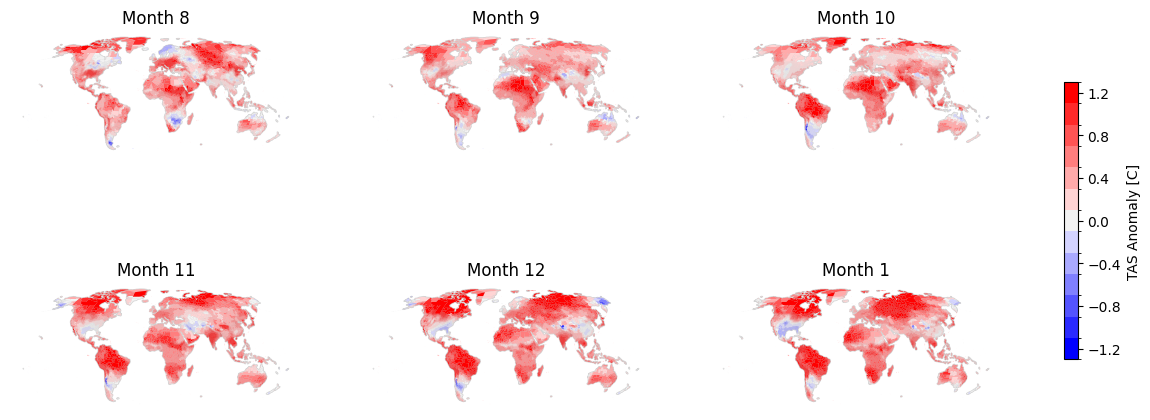

In [52]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col='value',
    cm = 'bwr',
    n_colors = 9,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)

fig.savefig("2608_monthly_anomaly.png", dpi = 600, bbox_inches="tight")

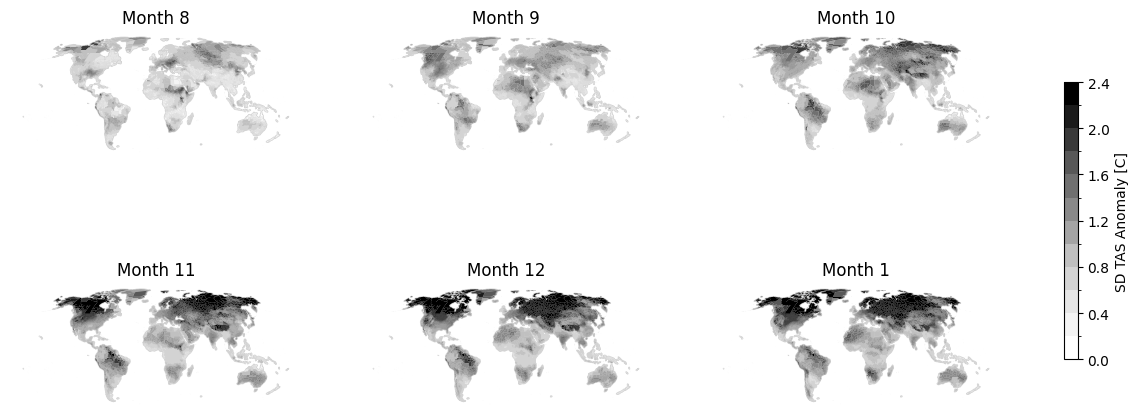

In [53]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly_std,
    col='value',
    cm = 'Grays',
    n_colors = 9,
    vmin = 0,
    sup_title=f"",
    cbar_label= 'SD TAS Anomaly [C]',
    month_order= [8, 9, 10, 11, 12, 1]
)

fig.savefig("2608_monthly_anomaly_std.png", dpi = 600, bbox_inches="tight")

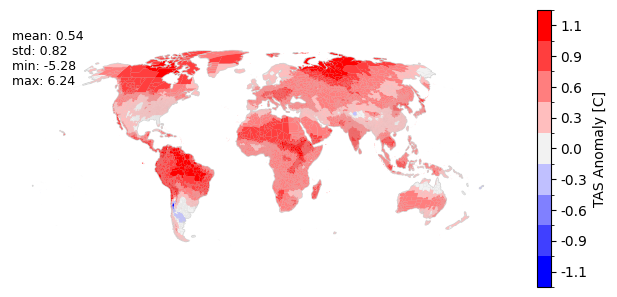

In [ ]:
#Validation Annotation
annotation = analysis_utils.build_stats_text(anomaly_ir.mean(dim = 'month'))
#6 month average anomaly
fig = analysis_utils.plot_aggregate(
    _polygons_anomaly,
    col='value',
    agg = 'mean',
    cm = 'bwr',
    n_colors = 7,
    annotation=annotation,
    sup_title=f"",
    cbar_label= 'TAS Anomaly [C]',
)

fig.savefig("2608_cum_anomaly.png", dpi = 600, bbox_inches="tight")

# QDM Bias Correction

# Climate Input Data (Bias-Corrected)

# Socioeconomic Input Data

# Projections

# Uncertainty